In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import binom
import pandas as pd
from itertools import accumulate

## Detection Probability Mass Function definition and visualization

In [3]:
usz_blue = '#005ae8'
usz_orange = '#f17900'

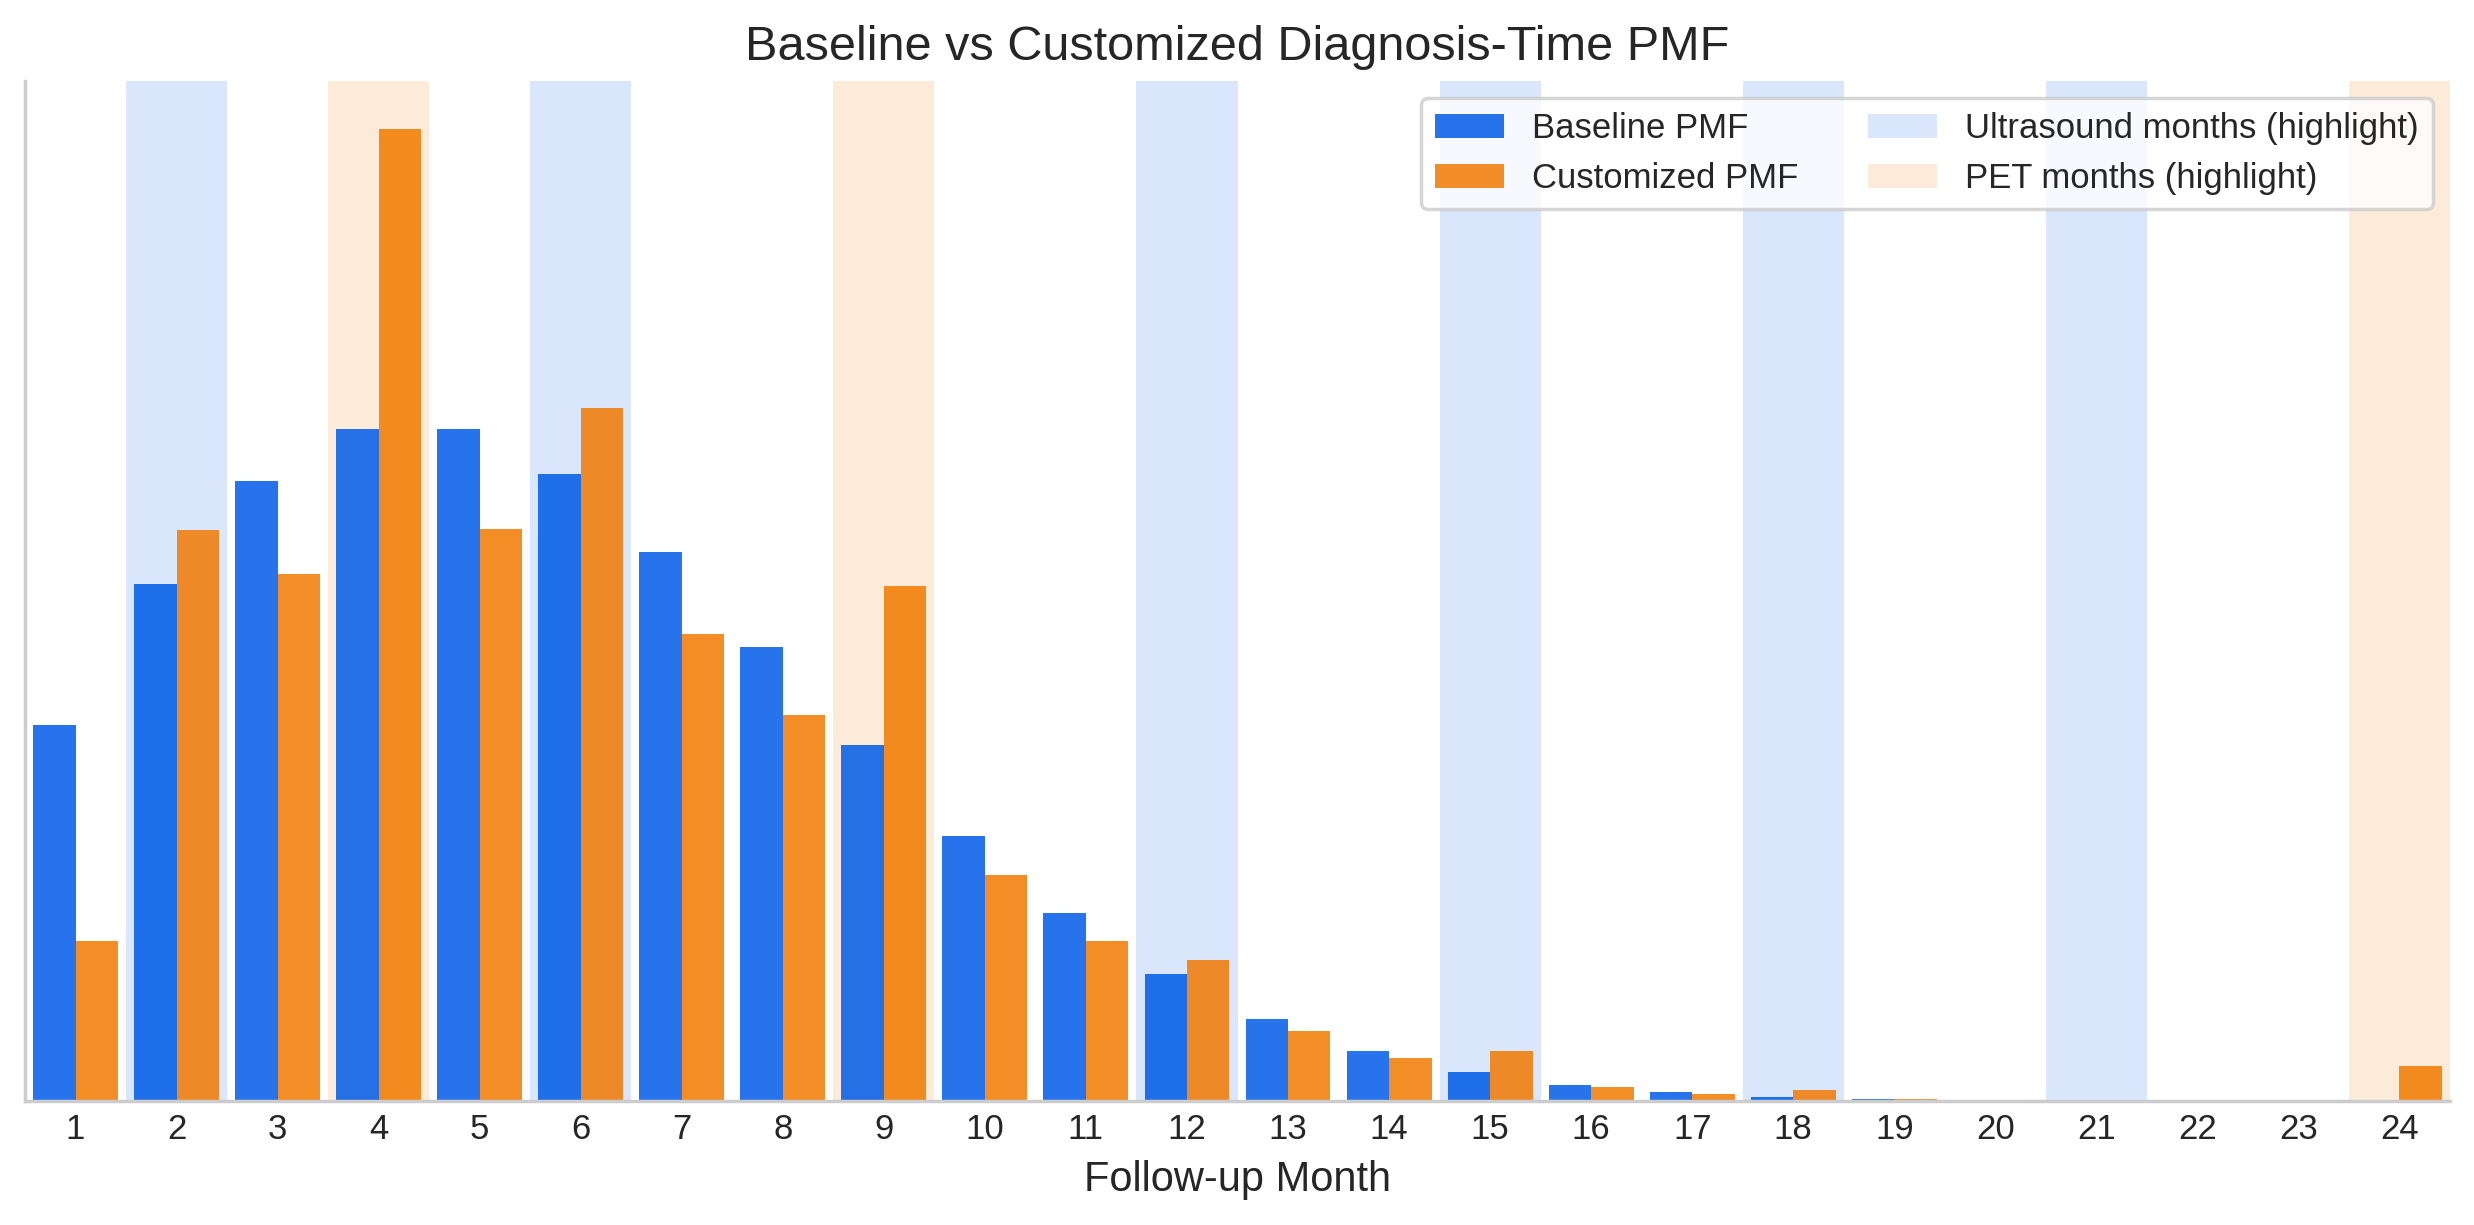

In [4]:
number_of_months = 24
x = np.arange(1, number_of_months + 1)
pmf = binom.pmf(x, number_of_months, 0.2)
pmf = pmf**0.3/(pmf**0.3).sum()

# Define weights based on examination
weights = np.ones_like(pmf)
weights_ultrasound = np.zeros_like(pmf)
weights_PET = np.zeros_like(pmf)

# Exam months (note: indices are 0-based, months are 1-based in x)
ultrasound_months = np.array([2, 6, 12, 15, 18, 21])
pet_months = np.array([4, 9, 24])

weights_ultrasound[ultrasound_months - 1] = 0.3
weights_PET[pet_months - 1] = 0.7

# some extra customization
weights += weights_ultrasound + weights_PET
weights[-1] = 4000
weights[14] = 2
weights[17] = 3
weights[0] = 0.5

# Apply weights to the PMF
weighted_pmf = pmf * weights

# Normalize the weighted PMF
weighted_pmf /= np.sum(weighted_pmf)

PMF = weighted_pmf.copy()


# ---- Plot (prettier) ----
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 250,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

fig, ax = plt.subplots(figsize=(10, 5))

# Subtle vertical highlights for exam months
for m in ultrasound_months:
    ax.axvspan(m - 0.5, m + 0.5, color=usz_blue, alpha=0.15, lw=0)
for m in pet_months:
    ax.axvspan(m - 0.5, m + 0.5, color=usz_orange, alpha=0.15, lw=0)

# Cleaner bars: same x, two bars with small offsets
bar_w = 0.42
ax.bar(x - bar_w / 2, pmf, width=bar_w, label='Baseline PMF', color=usz_blue, alpha=0.85)
ax.bar(x + bar_w / 2, weighted_pmf, width=bar_w, label='Customized PMF', color=usz_orange, alpha=0.85)

ax.set_xlabel('Follow-up Month')
# ax.set_ylabel('Probability')
ax.set_yticks([])
ax.set_title('Baseline vs Customized Diagnosis-Time PMF')
ax.set_xticks(np.arange(1, number_of_months + 1, 1))
ax.set_xlim(0.5, number_of_months + 0.5)
ax.margins(x=0)

# Make grid subtle
ax.grid(axis='y', alpha=0.25)
ax.grid(axis='x', alpha=0)

# Legend + note for highlights
from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
handles += [
    Patch(facecolor=usz_blue, alpha=0.15, edgecolor='none', label='Ultrasound months (highlight)'),
    Patch(facecolor=usz_orange, alpha=0.15, edgecolor='none', label='PET months (highlight)'),
 ]
ax.legend(handles=handles, ncols=2, frameon=True)

fig.tight_layout()
plt.show()

In [5]:
cdf = np.cumsum(PMF)

cdf_table = pd.DataFrame({
    "Month": x.astype(int),
    "CDF": cdf*100,
})

cdf_table

,Month,CDF
0,1,2.847019
1,2,13.008453
2,3,22.383729
3,4,39.676428
4,5,49.848605
5,6,62.177380
6,7,70.483743
7,8,77.354437
8,9,86.512313
9,10,90.526109


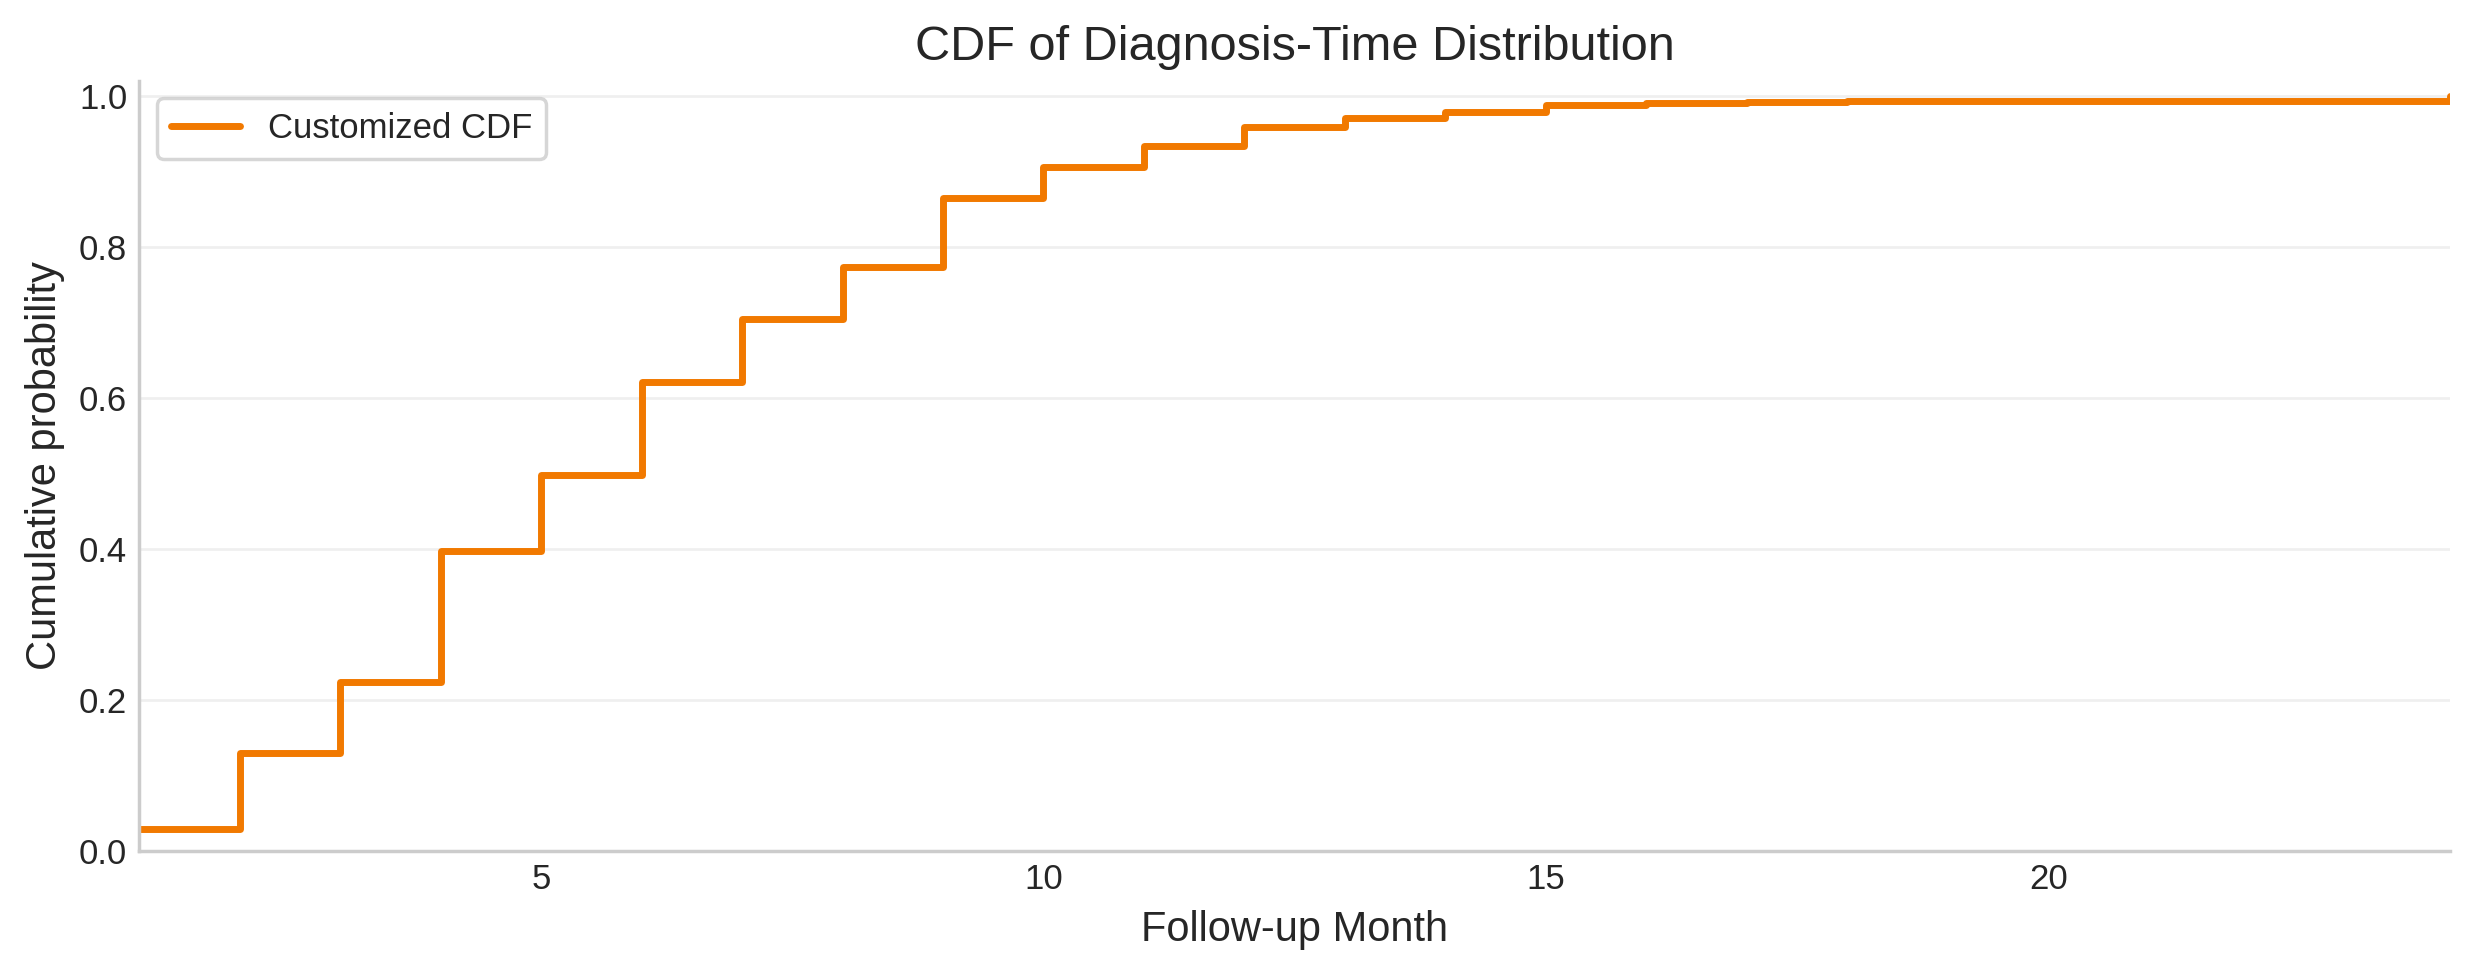

In [6]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 250,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(10, 4))

# Discrete CDFs are typically shown as step functions
ax.step(x, cdf, where="post", color=usz_orange, linewidth=2, label="Customized CDF")

ax.set_xlabel("Follow-up Month")
ax.set_ylabel("Cumulative probability")
ax.set_title("CDF of Diagnosis-Time Distribution")
ax.set_xlim(1, x.max())
ax.set_ylim(0, 1.02)
ax.grid(True, axis="y", alpha=0.3)
ax.grid(False, axis="x")
ax.legend(frameon=True, ncols=2)

fig.tight_layout()
plt.show()

## Recruitement process visualization

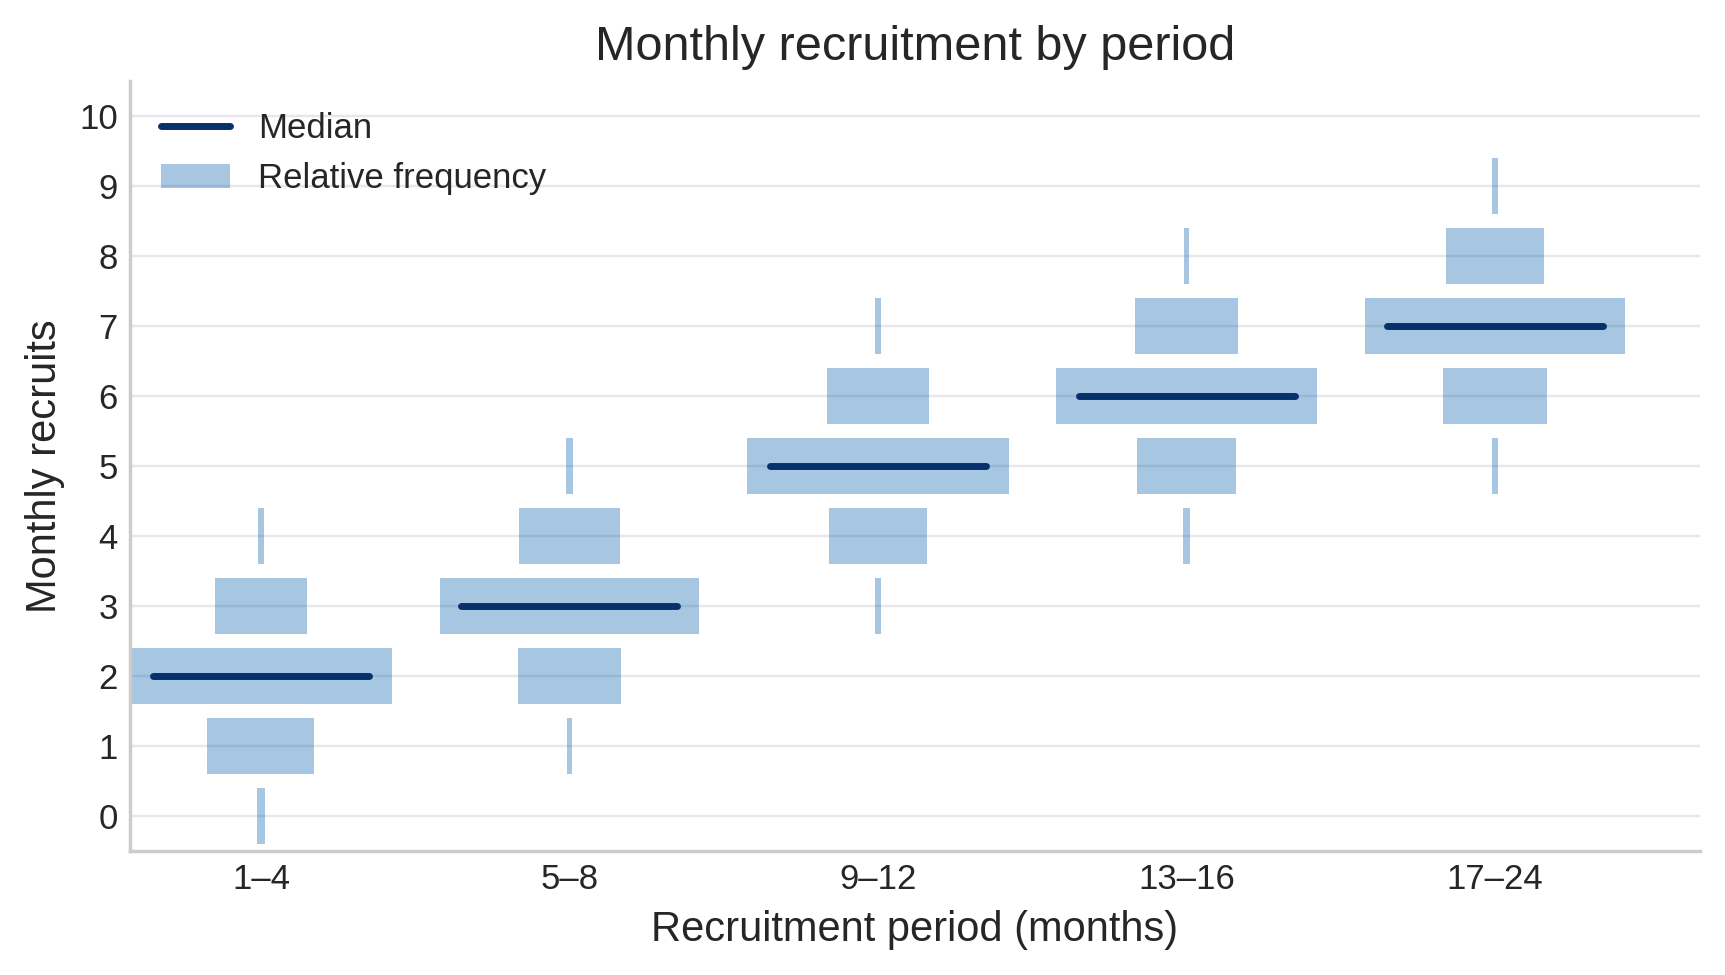

In [10]:
# --- Inputs: your period-level "typical" recruitment rates ---
period_labels = ['1–4', '5–8', '9–12', '13–16', '17–24']
recruitement_rate_list = np.array([2, 3, 5, 6, 7], dtype=float)

# --- Sampling model: mimic your month-specific Normal+clip logic ---
# Here we attach each period to the same distributions you implicitly use in rate_sampler().
# You can tune std/clip_max to match exactly what you want.
period_params = [
    dict(mu=2, sigma=2/3, clip_max=4),   # months 1–4
    dict(mu=3, sigma=2/3, clip_max=7),   # months 5–8
    dict(mu=5, sigma=4/6, clip_max=8),   # months 9–12
    dict(mu=6, sigma=4/6, clip_max=8),   # months 13–16
    dict(mu=7, sigma=4/6, clip_max=10),  # months 17–24
]

rng = np.random.default_rng(42)
n_draws = 2000  # how many "possible months" to simulate per period

samples_by_period = []
for p in period_params:
    s = rng.normal(p["mu"], p["sigma"], size=n_draws)
    s = np.round(s)
    s = np.clip(s, 0, p["clip_max"])
    samples_by_period.append(s)

# uncertainty (distribution of monthly draws)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(7, 4))

distributions = [np.unique(s, return_counts=True) for s in samples_by_period]
peak = max(counts.max() / counts.sum() for _, counts in distributions)

for i, (values, counts) in enumerate(distributions):
    widths = 0.85 * (counts / counts.sum()) / peak

    ax.barh(
        values, widths, left=i - widths / 2, height=0.8,
        color="#2171B5", alpha=0.4,
        label="Relative frequency" if i == 0 else None,
    )
    ax.plot(
        [i - 0.35, i + 0.35], [np.median(samples_by_period[i])] * 2,
        color="#08306B", lw=2, zorder=3,
        label="Median" if i == 0 else None,
    )

ax.set(
    xticks=np.arange(len(period_labels)), xticklabels=period_labels,
    xlabel="Recruitment period (months)", ylabel="Monthly recruits",
    title="Monthly recruitment by period",
    ylim=(-0.5, max(values.max() for values, _ in distributions) + 0.5),
)
ax.grid(False)
ax.set_axisbelow(True)
ax.grid(axis="y", color="#E5E7EB", linewidth=0.7)
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
plt.show()

In [11]:
# Define the sampler to sample the number of recruited patients per month
def rate_sampler(month):
    rate_change = [5,9,13,17]
    rate_index = 4 - (np.array(rate_change) > month).sum()
    if rate_index == 0:
        sample = np.round(np.random.normal(2,2/3,1))
        sample = np.clip(sample,0,4)
    elif rate_index == 1:
        sample = np.round(np.random.normal(3,2/3,1))
        sample = np.clip(sample,0,7)
    elif rate_index == 2:
        sample = np.round(np.random.normal(5,4/6,1))
        sample = np.clip(sample,0,8)
    elif rate_index == 3:
        sample = np.round(np.random.normal(6, 4/6, 1))
        sample = np.clip(sample, 0, 8)
    elif rate_index >= 4:
        sample = np.round(np.random.normal(7, 4/6, 1))
        sample = np.clip(sample, 0, 10)
    return sample

In [ ]:
def sample_custom_pmf(pmf = PMF, size=1):
    cdf = list(accumulate(pmf))
    return np.searchsorted(cdf, np.random.rand(size))+1

def full_recruiting_run(total_number_pat = 120, p0 = 0.1, pmf = PMF):
    number_of_follow_up_months = 24
    recruitement_list = np.zeros((total_number_pat,1))
    patients_time_count = np.zeros((total_number_pat,1))
    patient_true_status = np.zeros((total_number_pat,1))
    patient_observed_status = np.zeros((total_number_pat,1))
    recessive_patients_diagnose_time = np.zeros((total_number_pat,1))
    recruitement_month = np.zeros((total_number_pat,1))
    patient_index = 0 #index of actual patient to be recruited
    end_timer = -1
    month = 0
    while end_timer < number_of_follow_up_months:
        # update the already recruited patients
        patients_time_count[:patient_index] += 1
        for recruited_patient_index in range(0,total_number_pat):
            #update the observed status of the patients
            if patient_true_status[recruited_patient_index] == 1 and recessive_patients_diagnose_time[recruited_patient_index] == patients_time_count[recruited_patient_index]:
                patient_observed_status[recruited_patient_index] = 1
        #sample the number of recruited patients
        if patient_index < total_number_pat - 1:
            number_of_new_patients = int(rate_sampler(month)[0])
            if number_of_new_patients > (total_number_pat - 1)-patient_index:
                number_of_new_patients = (total_number_pat)-patient_index       
            # recruit the new patients and assign their true status         
            for _ in range(0,number_of_new_patients):
                patient_true_status[patient_index] = 0 if random.uniform(0,1) > p0 else 1
                recruitement_list[patient_index] = 1
                recruitement_month[patient_index] = month
                # assign diagnose time for positive patients
                if patient_true_status[patient_index] == 1:
                    recessive_patients_diagnose_time[patient_index] = int(sample_custom_pmf(pmf = pmf, size = 1)[0])
                patient_index += 1
        if patient_index >= total_number_pat - 1:
            end_timer += 1
        month += 1
   


    concatenated_data = np.concatenate((recruitement_list,recruitement_month, patients_time_count,patient_true_status, patient_observed_status, recessive_patients_diagnose_time), axis=1)
    df = pd.DataFrame(concatenated_data, columns=['Recruitement status','Month of recruitement', 'Months since recruitement', 'True recessive status', 'Observed status', 'diagnose time after treatment'])
    return df, month

df, month = full_recruiting_run(120, 0.1)

In [34]:
df_1, month_1 = full_recruiting_run(120, 0.1)
print(f'total positive patients recruited: {df_1["True recessive status"].sum()}, total observed positive patients: {df_1["Observed status"].sum()}, month duration: {month_1}')
df_2, month_2 = full_recruiting_run(120, 0.2)
print(f'total positive patients recruited: {df_2["True recessive status"].sum()}, total observed positive patients: {df_2["Observed status"].sum()}, month duration: {month_2}')

total positive patients recruited: 16.0, total observed positive patients: 16.0, month duration: 48
total positive patients recruited: 22.0, total observed positive patients: 22.0, month duration: 49


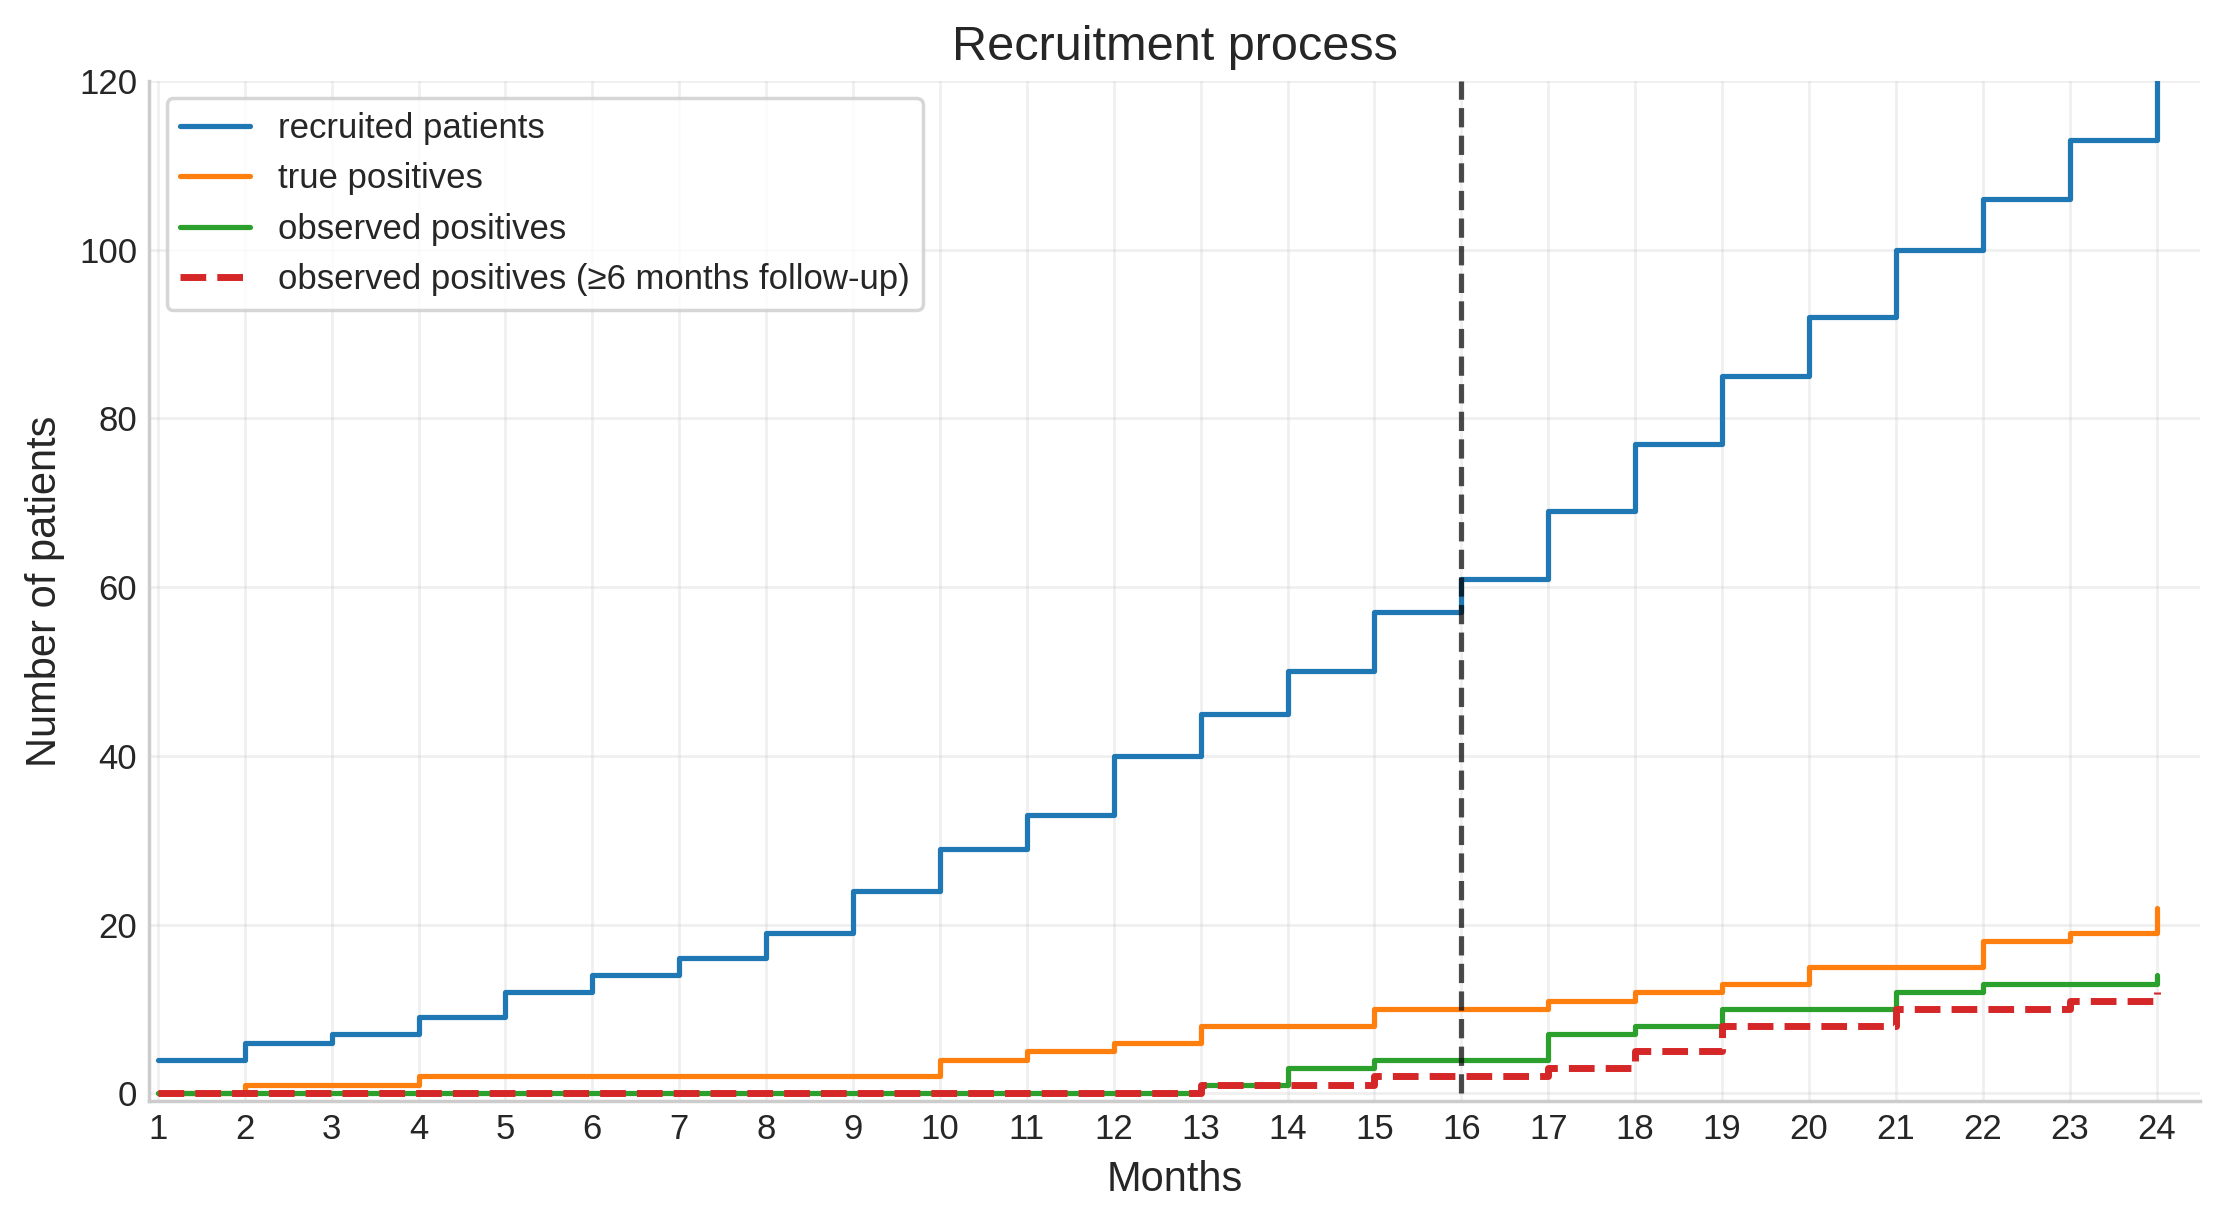

In [48]:
import numpy as np
import matplotlib.pyplot as plt

running_months = 24
minimum_follow_up = 6
months = np.arange(1, running_months + 1)

patients = df_2.loc[df_2["Recruitement status"] == 1]
positives = patients.loc[patients["True recessive status"] == 1]

recruitment_month = patients["Month of recruitement"]
positive_recruitment_month = positives["Month of recruitement"]
diagnose_time = positive_recruitment_month + positives["diagnose time after treatment"]

# Events count once diagnosis and six months of follow-up have both occurred.
eligible_event_time = np.maximum(
    diagnose_time, positive_recruitment_month + minimum_follow_up
)

def cumulative_count(times):
    return np.array([(times <= m).sum() for m in months])

cumulative_patients = cumulative_count(recruitment_month)
cumulative_positive = cumulative_count(positive_recruitment_month)
cumulative_observed = cumulative_count(diagnose_time)
cumulative_observed_6m = cumulative_count(eligible_event_time)

plt.figure(figsize=(9, 5))
plt.step(months, cumulative_patients, label="recruited patients", where="post")
plt.step(months, cumulative_positive, label="true positives", where="post")
plt.step(months, cumulative_observed, label="observed positives", where="post")
plt.step(
    months, cumulative_observed_6m, where="post",
    label="observed positives (≥6 months follow-up)",
    linestyle="--", linewidth=2,
)

plt.grid(visible=True, alpha=0.3)
plt.xlabel("Months")
plt.ylabel("Number of patients")
plt.xticks(months)
plt.title("Recruitment process")
plt.legend(frameon=True)
plt.tight_layout()
plt.vlines([16], ymin=0, ymax=120, color="black", linestyle="--", alpha= 0.7)
plt.ylim(-0.9, 120)
plt.xlim(0.9, 24.5)
plt.show()

## Final interim Analysis evaluation

In [25]:
def sample_custom_pmf(pmf = PMF, size=1):
    cdf = list(accumulate(pmf))
    return np.searchsorted(cdf, np.random.rand(size))+1

def interim_evaluator(patient_true_status,patient_actual_status,patients_time_count,recessive_patients_diagnose_time,minimum_follow_up, minimum_patients_at_interim = None):
    p0 = 0.10 #allowed under H0
    patients_to_consider = (patients_time_count >= minimum_follow_up).sum()
    stopp_trial_observed_after_break = 0
    additional_months = 0
    while patients_to_consider < minimum_patients_at_interim and minimum_patients_at_interim != None:
        patients_time_count += 1
        additional_months += 1
        for recruited_patient_index in range(0,len(patient_true_status)):
            #update the observed status of the patients
            if patient_true_status[recruited_patient_index] == 1:
                if recessive_patients_diagnose_time[recruited_patient_index] <= patients_time_count[recruited_patient_index]:
                    patient_actual_status[recruited_patient_index] = 1
        patients_to_consider = (patients_time_count >= minimum_follow_up).sum()
    pi_true = binom.sf(sum(patient_true_status[:patients_to_consider])-1, patients_to_consider, p0)   # P(K >= k)
    pi_actual = binom.sf(sum(patient_actual_status[:patients_to_consider])-1, patients_to_consider, p0)   # P(K >= k)
    stopp_trial_true = 1 if (pi_true < 0.10) else 0
    stopp_trial_observed = 1 if (pi_actual < 0.10) else 0
    if stopp_trial_observed == 1:
        patients_time_count += 6
        additional_months += 6 #careful, this changes how additional months behaves!
        for recruited_patient_index in range(0,len(patient_true_status)):
            #update the observed status of the patients
            if patient_true_status[recruited_patient_index] == 1:
                if recessive_patients_diagnose_time[recruited_patient_index] <= patients_time_count[recruited_patient_index]:
                    patient_actual_status[recruited_patient_index] = 1
        pi_end = binom.sf(sum(patient_actual_status[:len(patient_true_status),])-1, len(patient_true_status), p0)   # P(K >= k)
        stopp_trial_observed_after_break = 1 if (pi_end < 0.05) else 0
    
    return np.array([stopp_trial_true, stopp_trial_observed, patients_to_consider]), additional_months, stopp_trial_observed_after_break


def trial_interim_simulation(total_number_pat = 120, p0 = 0.1, interim = None, minimum_follow_up = 6, minimum_patients_at_interim = None, max_events = None, pmf = PMF):
    number_of_follow_up_months = 24
    recruitement_list = np.zeros((total_number_pat,1))
    patients_time_count = np.zeros((total_number_pat,1))
    patient_true_status = np.zeros((total_number_pat,1))
    patient_observed_status = np.zeros((total_number_pat,1))
    recessive_patients_diagnose_time = np.zeros((total_number_pat,1))
    recruitement_month = np.zeros((total_number_pat,1))
    patient_index = 0 #index of actual patient to be recruited
    end_timer = -1
    month = 0
    stopping_month = -1 #if we do not stop
    number_of_recruited_patients = 0  # Will be updated if early stopping occurs
    additional_months = 0       # Time added by interim analyses
    stop_after_break = 0        # Whether trial stopped after pause
    
    # Initialize interim analysis tracking
    if interim != None:
        interim_analyses = np.zeros((len(interim),3))
    else: 
        interim_analyses = 0
    interim_looper = 0
    
    while end_timer < number_of_follow_up_months:
        # === STEP 1: Update existing patients ===
        # update the already recruited patients
        patients_time_count[:patient_index] += 1
        
        for recruited_patient_index in range(0,total_number_pat):
            #update the observed status of the patients
            if patient_true_status[recruited_patient_index] == 1 and recessive_patients_diagnose_time[recruited_patient_index] <= patients_time_count[recruited_patient_index]:
                patient_observed_status[recruited_patient_index] = 1
                
        # === STEP 2: Check max events stopping rule ===
        # we stop if we surpass max events
        if patient_observed_status.sum() >= max_events:
            stopping_month = month
            concatenated_data = np.concatenate((recruitement_list,recruitement_month, patients_time_count,patient_true_status, patient_observed_status, recessive_patients_diagnose_time), axis=1)
            df = pd.DataFrame(concatenated_data, columns=['Recruitement status','Month of recruitement', 'Months since recruitement', 'True recessive status', 'Observed status', 'diagnose time after treatment'])
            return df, month, interim_analyses, additional_months, stop_after_break, stopping_month, number_of_recruited_patients
        
        # === STEP 3: Recruit new patients ===
        if patient_index < total_number_pat:
            number_of_new_patients = int(rate_sampler(month)[0])
            
            # Cap recruitment at remaining target and (if applicable) next interim target
            remaining_total = total_number_pat - patient_index

            if (interim is not None) and (interim_looper < len(interim)):
                remaining_to_next_interim = interim[interim_looper] - patient_index
                number_of_new_patients = min(number_of_new_patients, remaining_total, remaining_to_next_interim)
            else:
                number_of_new_patients = min(number_of_new_patients, remaining_total)
            
            # recruit the new patients and assign their true status         
            for _ in range(0,number_of_new_patients):
                patient_true_status[patient_index] = 0 if random.uniform(0,1) > p0 else 1
                recruitement_list[patient_index] = 1
                recruitement_month[patient_index] = month
                # assign diagnose time for positive patients
                if patient_true_status[patient_index] == 1:
                    recessive_patients_diagnose_time[patient_index] = int(sample_custom_pmf(pmf = pmf, size = 1)[0])
                patient_index += 1
        number_of_recruited_patients = recruitement_list.sum()

                
        # === STEP 4: Check for interim analysis triggers ===
        if (interim is not None) and (interim_looper < len(interim)) and (recruitement_list.sum() == interim[interim_looper]):
            # Conduct interim analysis on recruited patients
            interim_analyses[interim_looper], additional_months, stop_after_break = interim_evaluator(patient_true_status[:interim[interim_looper]].copy(),patient_observed_status[:interim[interim_looper]].copy(),patients_time_count[:interim[interim_looper]].copy(),recessive_patients_diagnose_time[:interim[interim_looper]].copy(), minimum_follow_up, minimum_patients_at_interim)
            interim_looper += 1
            
            # Fast-forward time by waiting/pause duration
            patients_time_count[:patient_index] += additional_months
            month += additional_months
            
            # Update all patient statuses after time skip
            #update the observed status of the patients at the end
            for recruited_patient_index in range(0,patient_index):
                if patient_true_status[recruited_patient_index] == 1:
                    if recessive_patients_diagnose_time[recruited_patient_index] <= patients_time_count[recruited_patient_index]:
                        patient_observed_status[recruited_patient_index] = 1     
            
            # Check if trial stopped permanently after pause
            if stop_after_break == 1:
                concatenated_data = np.concatenate((recruitement_list,recruitement_month, patients_time_count,patient_true_status, patient_observed_status, recessive_patients_diagnose_time), axis=1)
                df = pd.DataFrame(concatenated_data, columns=['Recruitement status','Month of recruitement', 'Months since recruitement', 'True recessive status', 'Observed status', 'diagnose time after treatment'])
                stopping_month = month
                return df, month, interim_analyses, additional_months, stop_after_break, stopping_month, number_of_recruited_patients
        
        if patient_index >= total_number_pat:
            end_timer += 1
        month += 1
   


    concatenated_data = np.concatenate((recruitement_list,recruitement_month, patients_time_count,patient_true_status, patient_observed_status, recessive_patients_diagnose_time), axis=1)
    df = pd.DataFrame(concatenated_data, columns=['Recruitement status','Month of recruitement', 'Months since recruitement', 'True recessive status', 'Observed status', 'diagnose time after treatment'])
    return df, month, interim_analyses, additional_months, stop_after_break, stopping_month, number_of_recruited_patients



example usage

In [ ]:
df, month, interim_analyses, additional_months, stop_after_break, stopping_month, number_of_recruited_patients = trial_interim_simulation(total_number_pat = 120, p0 = 0.25,interim=[60], minimum_follow_up=6, minimum_patients_at_interim = 20, max_events = 20)

interim_analyses[0] = [stopp_trial_true, stopp_trial_observed, N_evaluable]
we are mostly interested in stop_trial_observed and N_evaluable

In [ ]:
interim_analyses

array([[ 1.,  1., 32.]])

In [ ]:
number_of_simulations = 10000
total_number_of_patients = 120
patients_at_interim = [60]
p0 = 0.10
minimum_follow_up_months = 6
minimum_patients_at_followup = 20
maximum_number_of_events = 20

stopping_array_looper_10 = np.zeros((number_of_simulations,2))
interim_at_60_10 = np.zeros((number_of_simulations,4))
break_stopper_array_10 = np.zeros(number_of_simulations)
stopping_month_array_10 = np.zeros(number_of_simulations)
number_of_recruited_patients_array_10 = np.zeros(number_of_simulations)
dfs_10 = []
for i in range(0,number_of_simulations):
    df_looper, month_looper, interim_analyses_looper, additional_months_looper, stop_after_break_looper, stopping_month_looper, number_of_recruited_patients_looper = trial_interim_simulation(total_number_pat = total_number_of_patients, p0 = p0,interim=patients_at_interim, minimum_follow_up=minimum_follow_up_months, minimum_patients_at_interim = minimum_patients_at_followup, max_events = maximum_number_of_events)
    interim_at_60_10[i,:3] = interim_analyses_looper[0]
    interim_at_60_10[i,-1] = additional_months_looper
    break_stopper_array_10[i] = stop_after_break_looper
    stopping_month_array_10[i] = stopping_month_looper
    number_of_recruited_patients_array_10[i] = number_of_recruited_patients_looper
    dfs_10.append(df_looper)



In [ ]:
number_of_simulations = 10000
total_number_of_patients = 120
patients_at_interim = [60]
p0 = 0.15
minimum_follow_up_months = 6
minimum_patients_at_followup = 20
maximum_number_of_events = 20

stopping_array_looper_15 = np.zeros((number_of_simulations,2))
interim_at_60_15 = np.zeros((number_of_simulations,4))
break_stopper_array_15 = np.zeros(number_of_simulations)
stopping_month_array_15 = np.zeros(number_of_simulations)
number_of_recruited_patients_array_15 = np.zeros(number_of_simulations)
dfs_15 = []
for i in range(0,number_of_simulations):
    df_looper, month_looper, interim_analyses_looper, additional_months_looper, stop_after_break_looper, stopping_month_looper, number_of_recruited_patients_looper = trial_interim_simulation(total_number_pat = total_number_of_patients, p0 = p0,interim=patients_at_interim, minimum_follow_up=minimum_follow_up_months, minimum_patients_at_interim = minimum_patients_at_followup, max_events = maximum_number_of_events)
    interim_at_60_15[i,:3] = interim_analyses_looper[0]
    interim_at_60_15[i,-1] = additional_months_looper
    break_stopper_array_15[i] = stop_after_break_looper
    stopping_month_array_15[i] = stopping_month_looper
    number_of_recruited_patients_array_15[i] = number_of_recruited_patients_looper
    dfs_15.append(df_looper)



In [ ]:
number_of_simulations = 10000
total_number_of_patients = 120
patients_at_interim = [60]
p0 = 0.20
minimum_follow_up_months = 6
minimum_patients_at_followup = 20
maximum_number_of_events = 20

stopping_array_looper_20 = np.zeros((number_of_simulations,2))
interim_at_60_20 = np.zeros((number_of_simulations,4))
break_stopper_array_20 = np.zeros(number_of_simulations)
stopping_month_array_20 = np.zeros(number_of_simulations)
number_of_recruited_patients_array_20 = np.zeros(number_of_simulations)
dfs_20 = []
for i in range(0,number_of_simulations):
    df_looper, month_looper, interim_analyses_looper, additional_months_looper, stop_after_break_looper, stopping_month_looper, number_of_recruited_patients_looper = trial_interim_simulation(total_number_pat = total_number_of_patients, p0 = p0,interim=patients_at_interim, minimum_follow_up=minimum_follow_up_months, minimum_patients_at_interim = minimum_patients_at_followup, max_events = maximum_number_of_events)
    interim_at_60_20[i,:3] = interim_analyses_looper[0]
    interim_at_60_20[i,-1] = additional_months_looper
    break_stopper_array_20[i] = stop_after_break_looper
    stopping_month_array_20[i] = stopping_month_looper
    number_of_recruited_patients_array_20[i] = number_of_recruited_patients_looper
    dfs_20.append(df_looper)



In [ ]:
import numpy as np
import pandas as pd

def evaluate_trial_simulation_outputs(
    interim_at_60: np.ndarray,
    break_stopper_array: np.ndarray,
    stopping_month_array: np.ndarray,
    number_of_recruited_patients_array: np.ndarray,
    interim_target: int = 60,
    stopping_month_sentinel: float = -1,
    return_table: bool = True,
):
    """
    Evaluate Monte Carlo outputs from your trial simulation.

    Expected inputs
    --------------
    interim_at_60 : (n_sims, 4) array with columns:
        [0] pause_true (perfect information),
        [1] pause_observed (protocol decision / "break triggered"),
        [2] N_evaluable at interim,
        [3] additional_months added at interim evaluator (waiting + possible 6-month pause)

    break_stopper_array : (n_sims,) 0/1, stop after break
    stopping_month_array : (n_sims,) stopping month if max-events stop, else sentinel (default -1)
    number_of_recruited_patients_array : (n_sims,) final recruited patient count

    Returns
    -------
    results : dict of scalar metrics + optional pandas table
    """
    interim_at_60 = np.asarray(interim_at_60)
    break_stopper_array = np.asarray(break_stopper_array)
    stopping_month_array = np.asarray(stopping_month_array)
    number_of_recruited_patients_array = np.asarray(number_of_recruited_patients_array)

    n_sims = interim_at_60.shape[0]

    # Robustly coerce columns (handles (n,1) column vectors too)
    pause_obs  = np.asarray(interim_at_60[:, 1]).astype(float).ravel()
    N_eval     = np.asarray(interim_at_60[:, 2]).astype(float).ravel()
    added_mo   = np.asarray(interim_at_60[:, 3]).astype(float).ravel()

    stop_after_break = break_stopper_array.astype(float).ravel()
    stopping_month   = stopping_month_array.astype(float).ravel()
    n_recruited      = number_of_recruited_patients_array.astype(float).ravel()

    def rate(mask) -> float:
        mask = np.asarray(mask).astype(bool)
        return float(mask.mean()) if mask.size else float("nan")

    # Primary metrics
    reached_interim_rate = rate(n_recruited >= interim_target)
    pause_rate = rate(pause_obs == 1)
    stop_after_break_rate = rate(stop_after_break == 1)
    stop_max_events_rate = rate(stopping_month != stopping_month_sentinel)

    # >>> NEW: stopped before full recruitment (either max-events OR stop-after-break)
    total_number_pat = 120  # set this to your trial max; hardcoded to avoid changing signature
    stopped_early = (stop_after_break == 1) | (stopping_month != stopping_month_sentinel)
    stopped_before_full_recruitment_rate = rate(stopped_early & (n_recruited < total_number_pat))
    # <<<

    # Waiting-only vs pause timing (added_mo includes both mechanisms)
    wait_only_mask = (added_mo > 0) & (pause_obs == 0)
    wait_only_rate = rate(wait_only_mask)
    avg_wait_only_months = float(np.mean(added_mo[wait_only_mask])) if np.any(wait_only_mask) else 0.0

    pause_mask = (pause_obs == 1)
    avg_added_months_given_pause = float(np.mean(added_mo[pause_mask])) if np.any(pause_mask) else 0.0

    # Interim N diagnostics
    avg_N_eval = float(np.mean(N_eval))
    p25_N, p50_N, p75_N = [float(x) for x in np.percentile(N_eval, [25, 50, 75])]

    # Conditional: stop after break given pause happened
    if np.any(pause_mask):
        p_stop_after_break_given_pause = float(rate((stop_after_break == 1) & pause_mask) / rate(pause_mask))
    else:
        p_stop_after_break_given_pause = float("nan")

    results = {
        "n_sims": n_sims,
        "reached_interim_rate": reached_interim_rate,
        "pause_rate": pause_rate,
        "stop_after_break_rate": stop_after_break_rate,
        "stop_max_events_rate": stop_max_events_rate,

        # NEW output
        "stopped_before_full_recruitment_rate": stopped_before_full_recruitment_rate,

        "wait_only_rate": wait_only_rate,
        "avg_wait_only_months": avg_wait_only_months,
        "avg_added_months_given_pause": avg_added_months_given_pause,
        "avg_N_eval": avg_N_eval,
        "median_N_eval": p50_N,
        "iqr_N_eval": (p25_N, p75_N),
        "p_stop_after_break_given_pause": p_stop_after_break_given_pause,
    }

    if return_table:
        table = pd.DataFrame(
            [
                ("Reached interim (>= target recruited)", reached_interim_rate),
                ("Paused at interim (break triggered)", pause_rate),
                ("Stopped after break", stop_after_break_rate),
                ("Stopped due to max events (any time)", stop_max_events_rate),

                # NEW row
                ("Stopped before full recruitment", stopped_before_full_recruitment_rate),

                ("Had to wait for N>=min (without break)", wait_only_rate),
            ],
            columns=["Metric", "Rate"],
        )
        results["table"] = table

    return results


def print_evaluation(results: dict, rate_fmt: str = "{:.3%}") -> None:
    """
    Pretty-print results returned by evaluate_trial_simulation_outputs.
    """
    n = results.get("n_sims", None)
    print(f"\n=== Trial simulation evaluation (N = {n}) ===")

    if "table" in results:
        table = results["table"].copy()
        table["Rate"] = table["Rate"].map(lambda x: rate_fmt.format(x) if np.isfinite(x) else "NA")
        print(table.to_string(index=False, justify="left", col_space=2))
    else:
        # fallback if table wasn't requested
        for k, v in results.items():
            if isinstance(v, (float, int)) and "rate" in k:
                print(f"{k}: {rate_fmt.format(v)}")

    p25, p75 = results["iqr_N_eval"]
    print("\n=== Interim sample size diagnostics ===")
    print(f"Mean evaluable N at interim: {results['avg_N_eval']:.2f}")
    print(f"Median (IQR) N at interim: {results['median_N_eval']:.0f} ({p25:.0f}–{p75:.0f})")

    p_cond = results["p_stop_after_break_given_pause"]
    if np.isfinite(p_cond):
        print(f"\nP(stop after break | pause happened): {rate_fmt.format(p_cond)}")
    else:
        print("\nP(stop after break | pause happened): NA (no pauses occurred)")


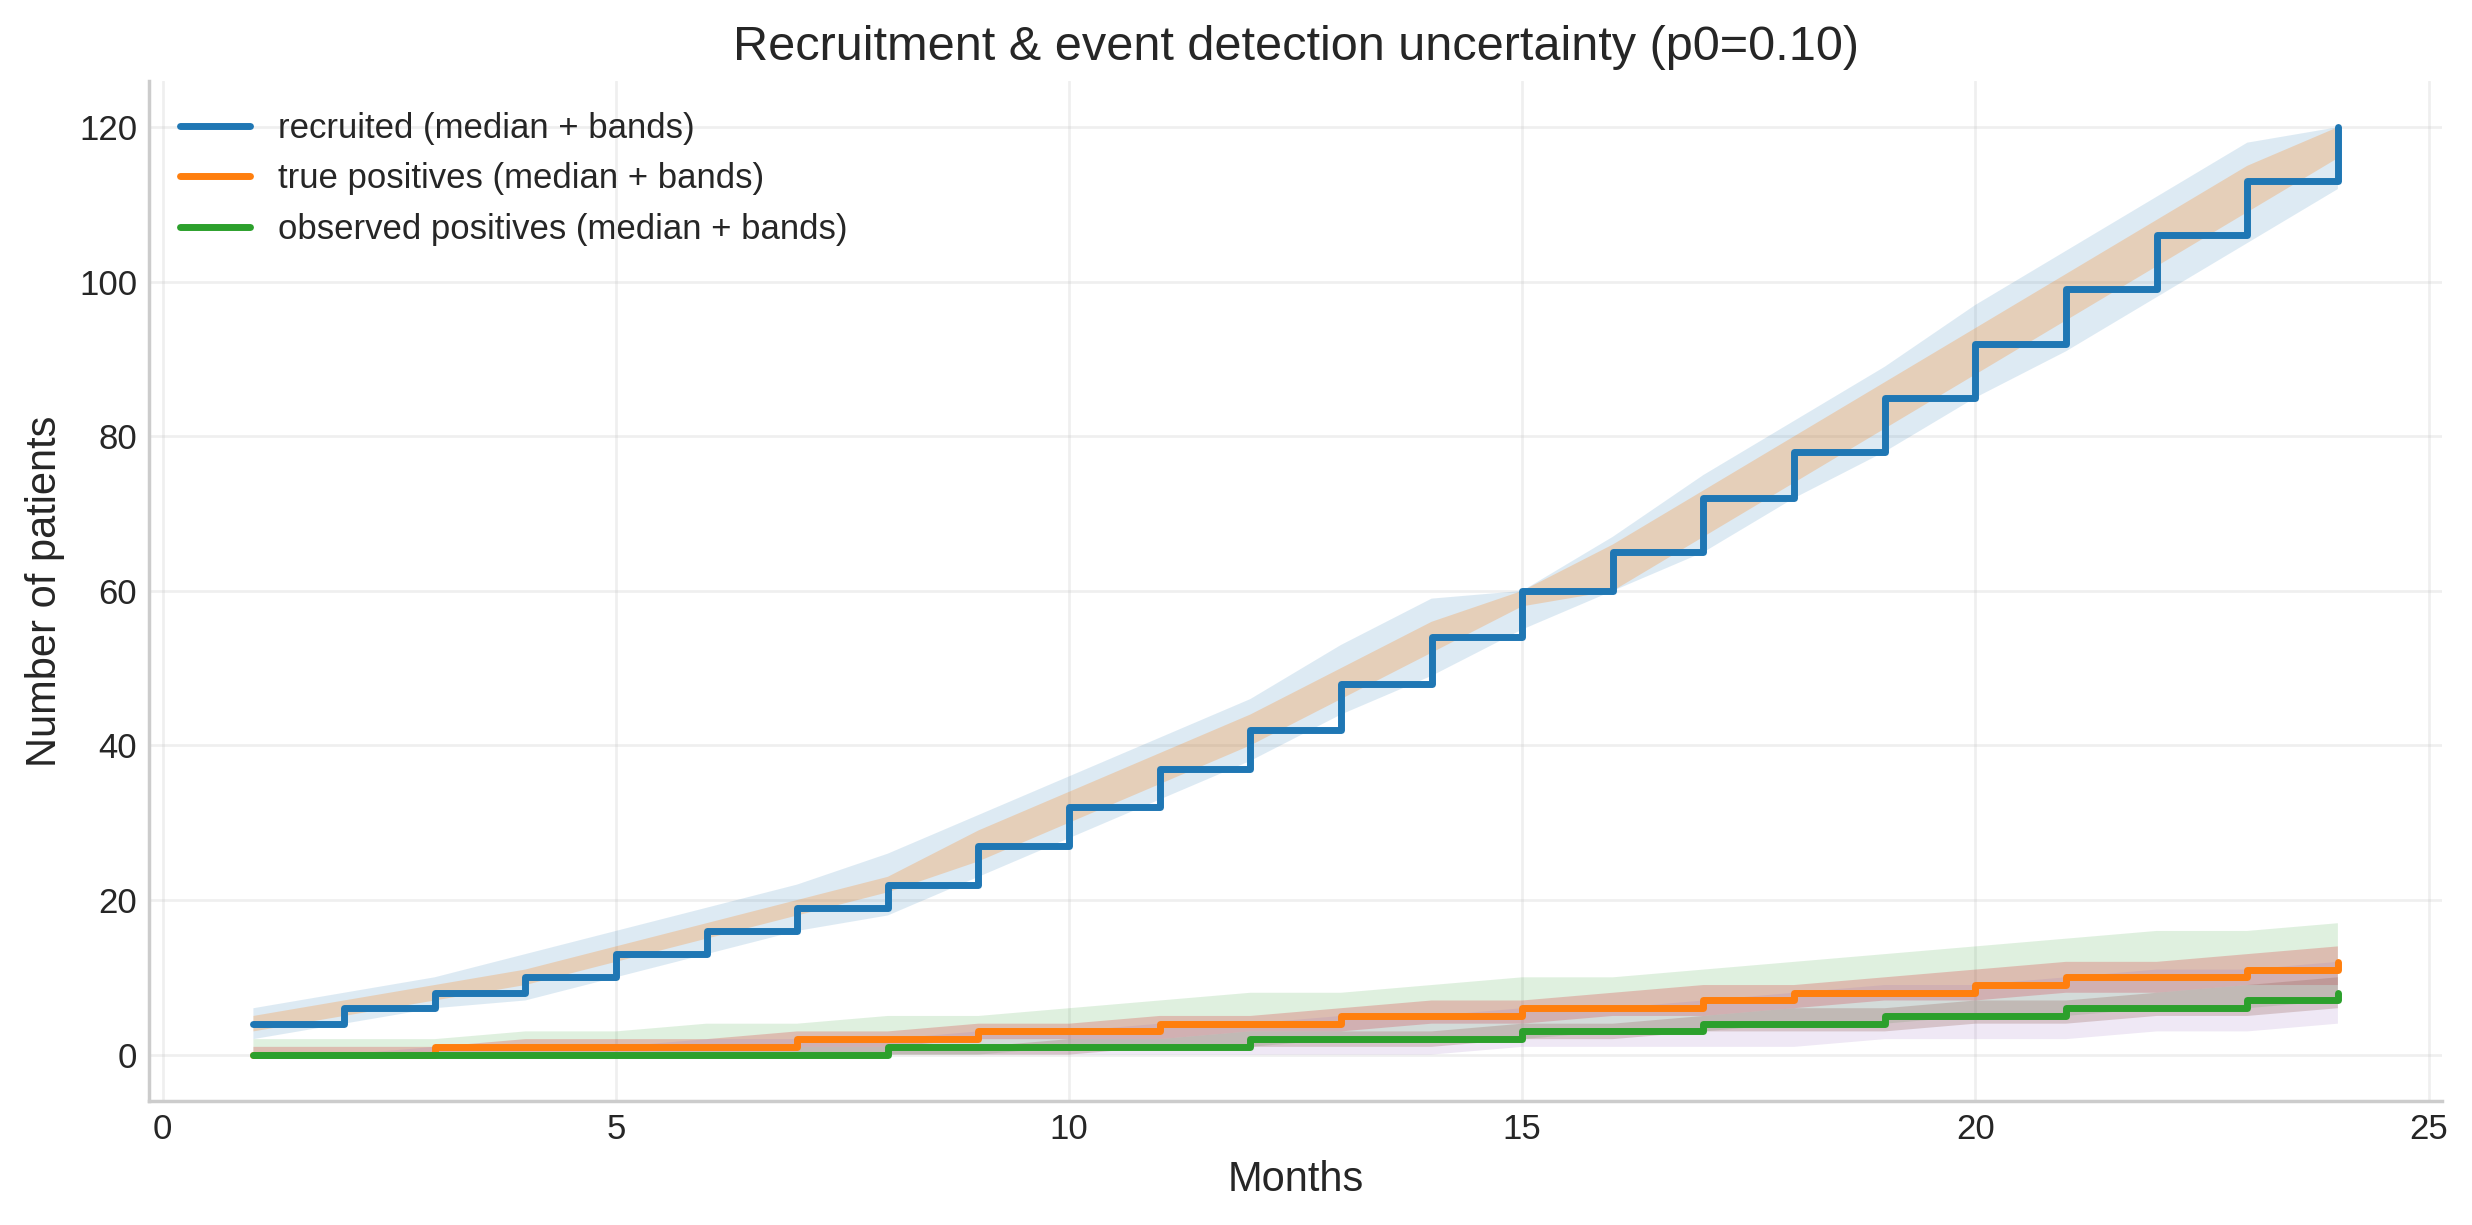

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def trajectories_from_df(df, months=24):
    # keep only recruited patients (in case df has trailing zeros)
    d = df[df["Recruitement status"] == 1].copy()

    rm = d["Month of recruitement"].to_numpy(dtype=float)
    y  = d["True recessive status"].to_numpy(dtype=float)
    dt = d["diagnose time after treatment"].to_numpy(dtype=float)

    # observed month (when it becomes observable)
    obs_month = rm + dt

    t = np.arange(1, months + 1)

    recruited = np.array([(rm <= ti).sum() for ti in t], dtype=float)
    true_pos  = np.array([((rm <= ti) & (y == 1)).sum() for ti in t], dtype=float)
    obs_pos   = np.array([((obs_month <= ti) & (y == 1)).sum() for ti in t], dtype=float)

    return recruited, true_pos, obs_pos

def compute_bands(dfs, months=24):
    R, T, O = [], [], []
    for df in dfs:
        r, t, o = trajectories_from_df(df, months=months)
        R.append(r); T.append(t); O.append(o)

    R = np.vstack(R); T = np.vstack(T); O = np.vstack(O)
    # quantiles across simulations at each month
    qs = [0.05, 0.25, 0.50, 0.75, 0.95]
    bands = {
        "R": np.quantile(R, qs, axis=0),
        "T": np.quantile(T, qs, axis=0),
        "O": np.quantile(O, qs, axis=0),
    }
    return bands

def plot_uncertainty_ribbons(dfs, months=24, title="Recruitment & event detection uncertainty"):
    bands = compute_bands(dfs, months=months)
    t = np.arange(1, months + 1)

    fig = plt.figure(figsize=(10, 5))
    ax = plt.gca()

    def ribbon(q, label):
        q05, q25, q50, q75, q95 = q
        ax.fill_between(t, q05, q95, alpha=0.15)
        ax.fill_between(t, q25, q75, alpha=0.25)
        ax.step(t, q50, where="post", linewidth=2, label=label)

    ribbon(bands["R"], "recruited (median + bands)")
    ribbon(bands["T"], "true positives (median + bands)")
    ribbon(bands["O"], "observed positives (median + bands)")

    ax.set_title(title)
    ax.set_xlabel("Months")
    ax.set_ylabel("Number of patients")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_uncertainty_ribbons(dfs_10, months=24, title="Recruitment & event detection uncertainty (p0=0.10)")

In [ ]:
results = evaluate_trial_simulation_outputs(
    interim_at_60=interim_at_60_10,
    break_stopper_array=break_stopper_array_10,
    stopping_month_array=stopping_month_array_10,
    number_of_recruited_patients_array=number_of_recruited_patients_array_10,
    interim_target=60,
)
print_evaluation(results)


=== Trial simulation evaluation (N = 10000) ===
Metric                                 Rate    
 Reached interim (>= target recruited) 100.000%
   Paused at interim (break triggered)   3.110%
                   Stopped after break   0.860%
  Stopped due to max events (any time)   2.240%
       Stopped before full recruitment   0.860%
Had to wait for N>=min (without break)   0.000%

=== Interim sample size diagnostics ===
Mean evaluable N at interim: 29.03
Median (IQR) N at interim: 29 (28–30)

P(stop after break | pause happened): 27.653%


In [ ]:
def plot_stopping_month_hist(stopping_month_array, months=24):
    stop_month = np.asarray(stopping_month_array).astype(int)
    stopped = stop_month[stop_month != -1]

    plt.figure(figsize=(10, 4))
    plt.hist(stopped, bins=np.arange(0, months + 2) - 0.5)
    plt.xlabel("Stopping month (max-events)")
    plt.ylabel("Count")
    plt.title("Distribution of max-events stopping month")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
results_15 = evaluate_trial_simulation_outputs(
    interim_at_60=interim_at_60_15,
    break_stopper_array=break_stopper_array_15,
    stopping_month_array=stopping_month_array_15,
    number_of_recruited_patients_array=number_of_recruited_patients_array_15,
    interim_target=60,
)
print_evaluation(results_15)


=== Trial simulation evaluation (N = 10000) ===
Metric                                 Rate    
 Reached interim (>= target recruited) 100.000%
   Paused at interim (break triggered)  15.240%
                   Stopped after break   8.610%
  Stopped due to max events (any time)  34.980%
       Stopped before full recruitment   9.180%
Had to wait for N>=min (without break)   0.000%

=== Interim sample size diagnostics ===
Mean evaluable N at interim: 29.03
Median (IQR) N at interim: 29 (28–30)

P(stop after break | pause happened): 56.496%


In [ ]:
results = evaluate_trial_simulation_outputs(
    interim_at_60=interim_at_60_20,
    break_stopper_array=break_stopper_array_20,
    stopping_month_array=stopping_month_array_20,
    number_of_recruited_patients_array=number_of_recruited_patients_array_20,
    interim_target=60,
)
print_evaluation(results)


=== Trial simulation evaluation (N = 10000) ===
Metric                                 Rate    
 Reached interim (>= target recruited) 100.000%
   Paused at interim (break triggered)  35.940%
                   Stopped after break  29.540%
  Stopped due to max events (any time)  85.770%
       Stopped before full recruitment  36.250%
Had to wait for N>=min (without break)   0.000%

=== Interim sample size diagnostics ===
Mean evaluable N at interim: 28.99
Median (IQR) N at interim: 29 (28–30)

P(stop after break | pause happened): 82.193%


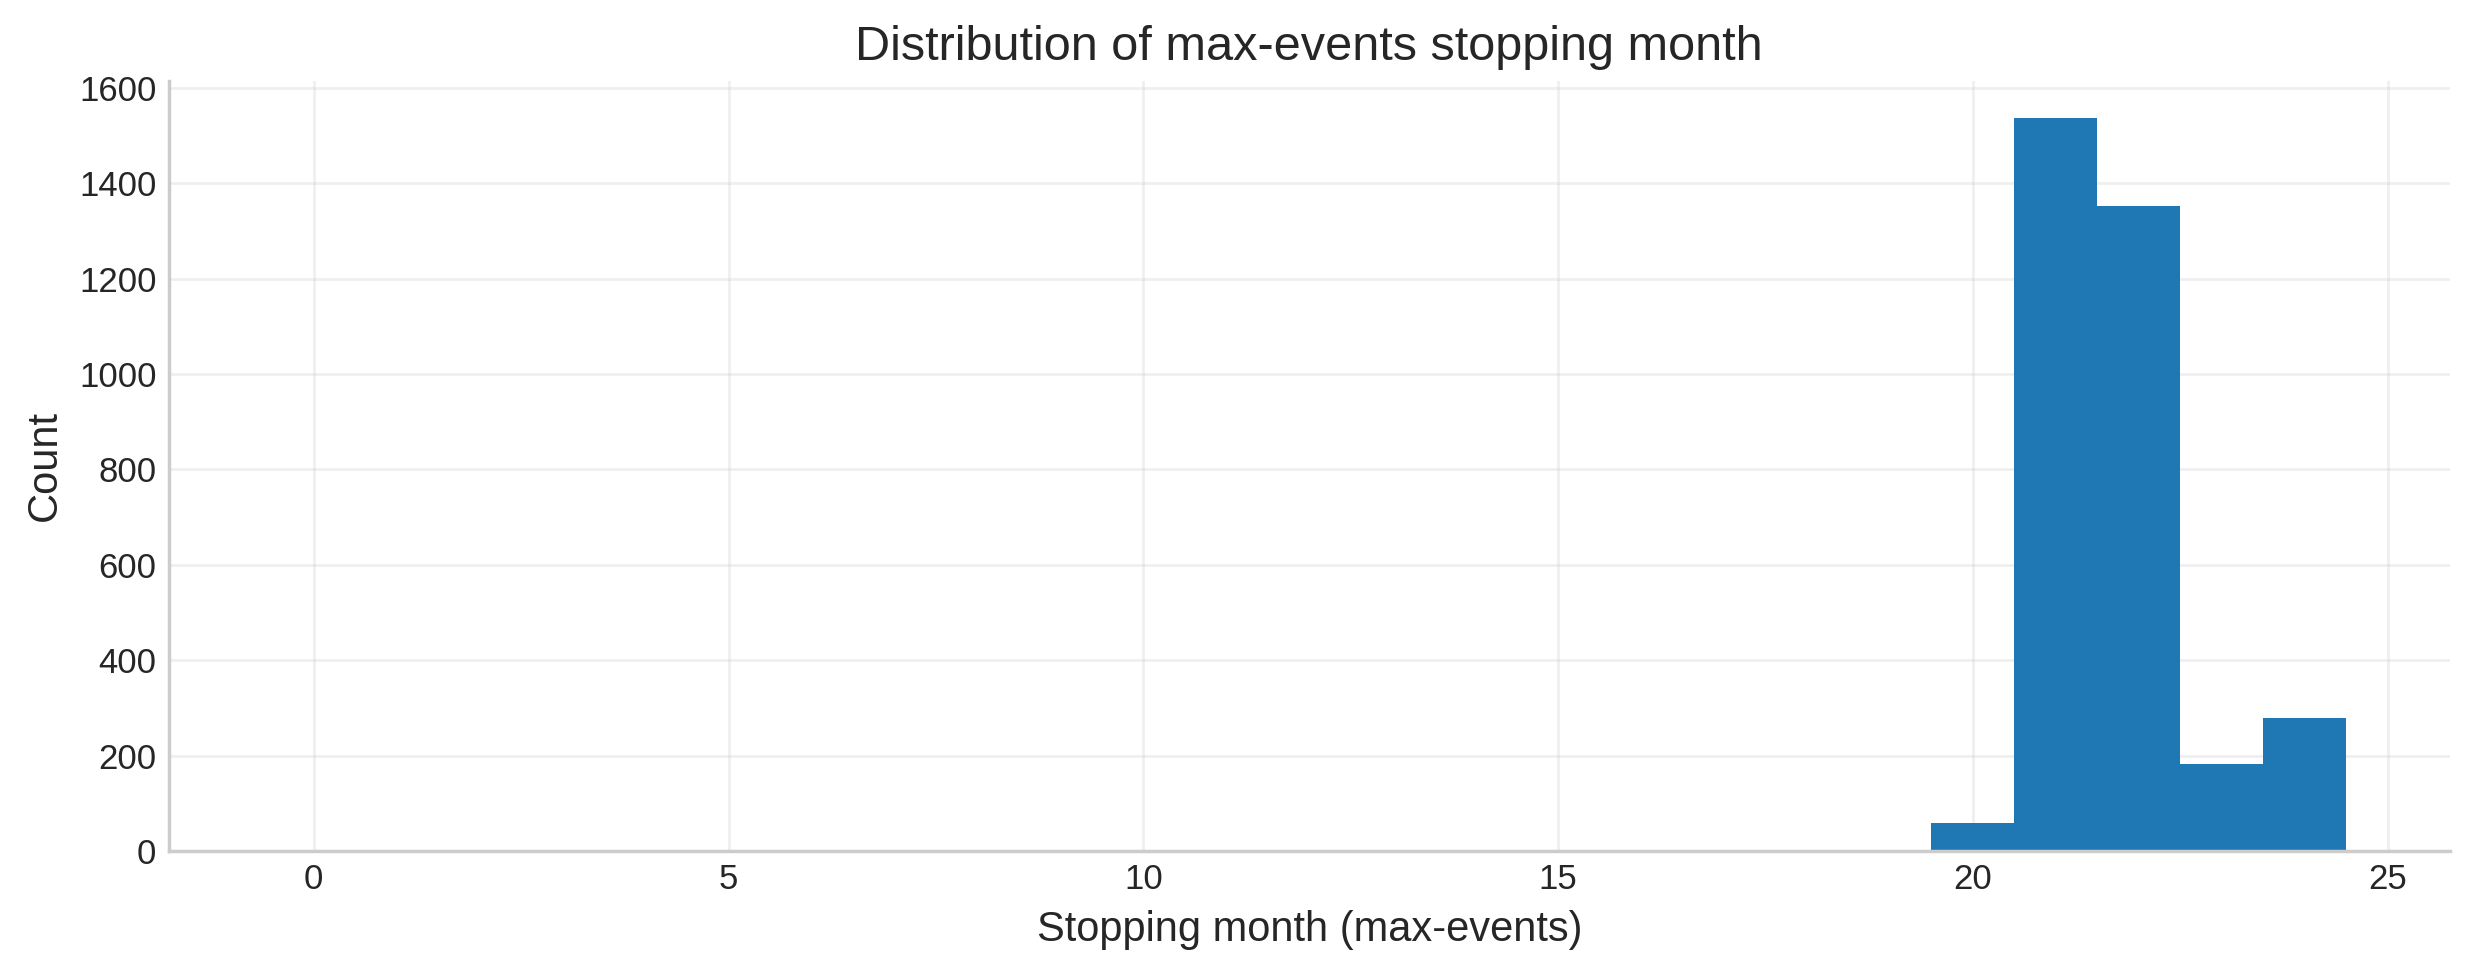

In [ ]:
plot_stopping_month_hist(stopping_month_array_20, months=24)